In [1]:
# ============================================================
# 1. CARGA E INSPECCIÓN DEL DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# RUTAS
# ------------------------------------------------------------

BASE_DIR = Path(
    "/home/cristian/Documentos/Proyectos/parasol-rag-architecture"
)

OUTDOOR_DIR = BASE_DIR / "data" / "anomaly" / "outdoor"

ANOMALY_FILE = OUTDOOR_DIR / "anomaly_scored_dataset.parquet"
PCE_FILE = OUTDOOR_DIR / "pce_norm_predictions.parquet"
PFF_FILE = OUTDOOR_DIR / "pff_predictions.parquet"

FIG_DIR = BASE_DIR / "data" / "anomaly" / "diagnostics" / "autopsy"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CARGA
# ------------------------------------------------------------

df = pd.read_parquet(ANOMALY_FILE)

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

# Orden temporal
df = df.sort_values(
    ["cell_name", "Timestamp"]
).reset_index(drop=True)

# ------------------------------------------------------------
# PARÁMETROS DEL ESTUDIO
# ------------------------------------------------------------

CASE_CELL = "A170AB302"

HEALTHY_CELLS = [
    "M83AB302",
    "ASLRXAB341",
]

FAILED_CELLS = [
    "P12",
    "M0",
]

EARLY_DAYS = 14

# Umbral que queremos investigar
BASE_THRESHOLD = 0.025
THRESHOLD_X3 = BASE_THRESHOLD * 3

# Umbral de frecuencia acumulada
ALERT_FREQ_LIMIT = 0.15

# ------------------------------------------------------------
# INFORMACIÓN BÁSICA
# ------------------------------------------------------------

print("=" * 80)
print("ANOMALY SCORED DATASET")
print("=" * 80)

print(f"\nFilas    : {len(df):,}")
print(f"Columnas : {len(df.columns)}")

print("\nPeriodo temporal:")
print(f"  Inicio : {df['Timestamp'].min()}")
print(f"  Final  : {df['Timestamp'].max()}")

print("\nNúmero de celdas:")
print(df["cell_name"].nunique())

# ------------------------------------------------------------
# CELDAS PRESENTES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELDAS PRESENTES")
print("=" * 80)

cell_summary = (
    df.groupby("cell_name")
      .agg(
          rows=("cell_name", "size"),
          start=("Timestamp", "min"),
          end=("Timestamp", "max"),
          exposure_days=("Exposure_Days", "max"),
          failure=("extrinsic_failure", "max"),
          survival_days=("survival_days", "max"),
          alert_pct=("Digital_Twin_Alert", "mean"),
      )
      .reset_index()
)

cell_summary["alert_pct"] *= 100

display(
    cell_summary.sort_values("cell_name")
)

# ------------------------------------------------------------
# COMPROBAR LAS CELDAS DE INTERÉS
# ------------------------------------------------------------

interesting_cells = [
    CASE_CELL,
    *HEALTHY_CELLS,
    *FAILED_CELLS,
]

print("\n" + "=" * 80)
print("CELDAS DE INTERÉS")
print("=" * 80)

for cell in interesting_cells:

    exists = cell in set(
        df["cell_name"].astype(str)
    )

    print(
        f"{cell:15s} -> "
        f"{'OK' if exists else 'NO ENCONTRADA'}"
    )

# ------------------------------------------------------------
# COLUMNAS RELEVANTES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COLUMNAS DEL GEMELO DIGITAL")
print("=" * 80)

relevant_columns = [
    "cell_name",
    "Timestamp",
    "Exposure_Days",
    "pFF",
    "PCE",
    "Twin_pFF_Pred",
    "Twin_PCE_Pred",
    "Underperformance_pFF",
    "Underperformance_PCE",
    "Alert_pFF",
    "Alert_PCE",
    "Digital_Twin_Alert",
    "In_Action_Window",
    "T80_Threshold",
    "extrinsic_failure",
    "threshold_15pct_day",
    "survival_days",
]

display(df[relevant_columns].head(10))

ANOMALY SCORED DATASET

Filas    : 47,302
Columnas : 31

Periodo temporal:
  Inicio : 2025-09-22 19:01:35.416618+00:00
  Final  : 2026-06-29 21:13:54.760125+00:00

Número de celdas:
8

CELDAS PRESENTES


,cell_name,rows,start,end,exposure_days,failure,survival_days,alert_pct
0,A162ALXP01,6836,2026-03-14 09:06:39.809554+00:00,2026-06-29 19:55:22.099080+00:00,9.394881,True,9.395,0.160913
1,A164AB302c,6891,2026-03-12 08:15:29.740665+00:00,2026-06-29 20:57:24.196413+00:00,28.479569,False,28.480,1.567262
2,A167AB344a,6969,2026-03-12 10:37:05.758448+00:00,2026-06-29 21:13:54.760125+00:00,56.278858,False,56.279,0.200890
3,A170AB302,1301,2026-03-12 08:32:03.359563+00:00,2026-04-07 17:01:16.512251+00:00,6.401299,True,6.401,2.767102
4,ASLRXAB341,7080,2026-03-14 09:11:00.825802+00:00,2026-06-29 20:59:02.923147+00:00,54.334147,False,54.334,0.423729
5,M0,3878,2025-09-22 19:01:35.416618+00:00,2026-02-18 11:52:13.784278+00:00,4.002558,True,4.003,7.297576
6,M83AB302,1380,2026-04-08 14:26:35.514725+00:00,2026-05-02 19:08:50.634010+00:00,23.176854,False,23.177,7.681159
7,P12,12967,2025-09-22 19:08:58.972462+00:00,2026-03-07 10:22:30.735849+00:00,21.979015,True,21.979,11.498419



CELDAS DE INTERÉS
A170AB302       -> OK
M83AB302        -> OK
ASLRXAB341      -> OK
P12             -> OK
M0              -> OK

COLUMNAS DEL GEMELO DIGITAL


,cell_name,Timestamp,Exposure_Days,pFF,PCE,Twin_pFF_Pred,Twin_PCE_Pred,Underperformance_pFF,Underperformance_PCE,Alert_pFF,Alert_PCE,Digital_Twin_Alert,In_Action_Window,T80_Threshold,extrinsic_failure,threshold_15pct_day,survival_days
0,A162ALXP01,2026-03-14 09:06:39.809554+00:00,NaN,0.400966,0.000000,NaN,NaN,NaN,NaN,None,None,False,None,NaN,True,NaN,9.395
1,A162ALXP01,2026-03-14 09:16:40.019092+00:00,NaN,0.423672,0.000000,NaN,NaN,NaN,NaN,None,None,False,None,NaN,True,NaN,9.395
2,A162ALXP01,2026-03-14 09:26:40.140057+00:00,NaN,0.432762,0.000000,NaN,NaN,NaN,NaN,None,None,False,None,NaN,True,NaN,9.395
3,A162ALXP01,2026-03-14 09:36:40.250748+00:00,0.020838,0.411908,7.792310,0.416849,7.826141,0.004942,0.033831,False,False,False,True,7.887517,True,NaN,9.395
4,A162ALXP01,2026-03-14 09:46:40.335721+00:00,0.027784,0.432370,7.660583,0.422034,8.656106,-0.010336,0.995524,False,False,False,True,7.887517,True,NaN,9.395
5,A162ALXP01,2026-03-14 09:56:40.399429+00:00,0.034729,0.380866,8.105358,0.423061,8.807242,0.042195,0.701884,False,False,False,True,7.887517,True,NaN,9.395
6,A162ALXP01,2026-03-14 10:06:40.377511+00:00,0.041673,0.421993,7.218987,0.411355,8.703843,-0.010637,1.484856,False,False,False,True,7.887517,True,NaN,9.395
7,A162ALXP01,2026-03-14 10:26:55.112705+00:00,0.055733,0.406130,7.487782,0.414577,7.657000,0.008447,0.169218,False,False,False,True,7.887517,True,NaN,9.395
8,A162ALXP01,2026-03-14 10:47:09.713558+00:00,0.069791,0.375338,5.979177,0.415081,7.381596,0.039743,1.402420,False,False,False,True,7.887517,True,NaN,9.395
9,A162ALXP01,2026-03-14 10:57:09.699913+00:00,0.076735,0.379006,6.867123,0.413982,5.680953,0.034976,-1.186170,False,False,False,True,7.887517,True,NaN,9.395


In [2]:
# ============================================================
# 2. PREPARACIÓN DEL ANÁLISIS
# ============================================================

# Asegurar tipos numéricos
numeric_columns = [
    "Exposure_Days",
    "pFF",
    "Twin_pFF_Pred",
    "Underperformance_pFF",
    "Alert_pFF",
    "Digital_Twin_Alert",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# Residuo del Gemelo Digital
df["Residual_pFF"] = (
    df["pFF"] -
    df["Twin_pFF_Pred"]
)

df["Abs_Residual_pFF"] = (
    df["Residual_pFF"].abs()
)

# Fases
df["Early_Phase"] = (
    df["Exposure_Days"] <= EARLY_DAYS
)

df["Mature_Phase"] = (
    df["Exposure_Days"] > EARLY_DAYS
)

print("=" * 80)
print("PREPARACIÓN COMPLETADA")
print("=" * 80)

print("\nVariables creadas:")
print("  Residual_pFF")
print("  Abs_Residual_pFF")
print("  Early_Phase")
print("  Mature_Phase")

print(
    f"\nObservaciones primeros {EARLY_DAYS} días: "
    f"{df['Early_Phase'].sum():,}"
)

print(
    f"Observaciones fase madura: "
    f"{df['Mature_Phase'].sum():,}"
)

PREPARACIÓN COMPLETADA

Variables creadas:
  Residual_pFF
  Abs_Residual_pFF
  Early_Phase
  Mature_Phase

Observaciones primeros 14 días: 6,016
Observaciones fase madura: 7,168


Sana            | M83AB302     |  814 observaciones con predicción
Fallo claro     | P12          | 1514 observaciones con predicción
Caso límite     | A170AB302    |  389 observaciones con predicción


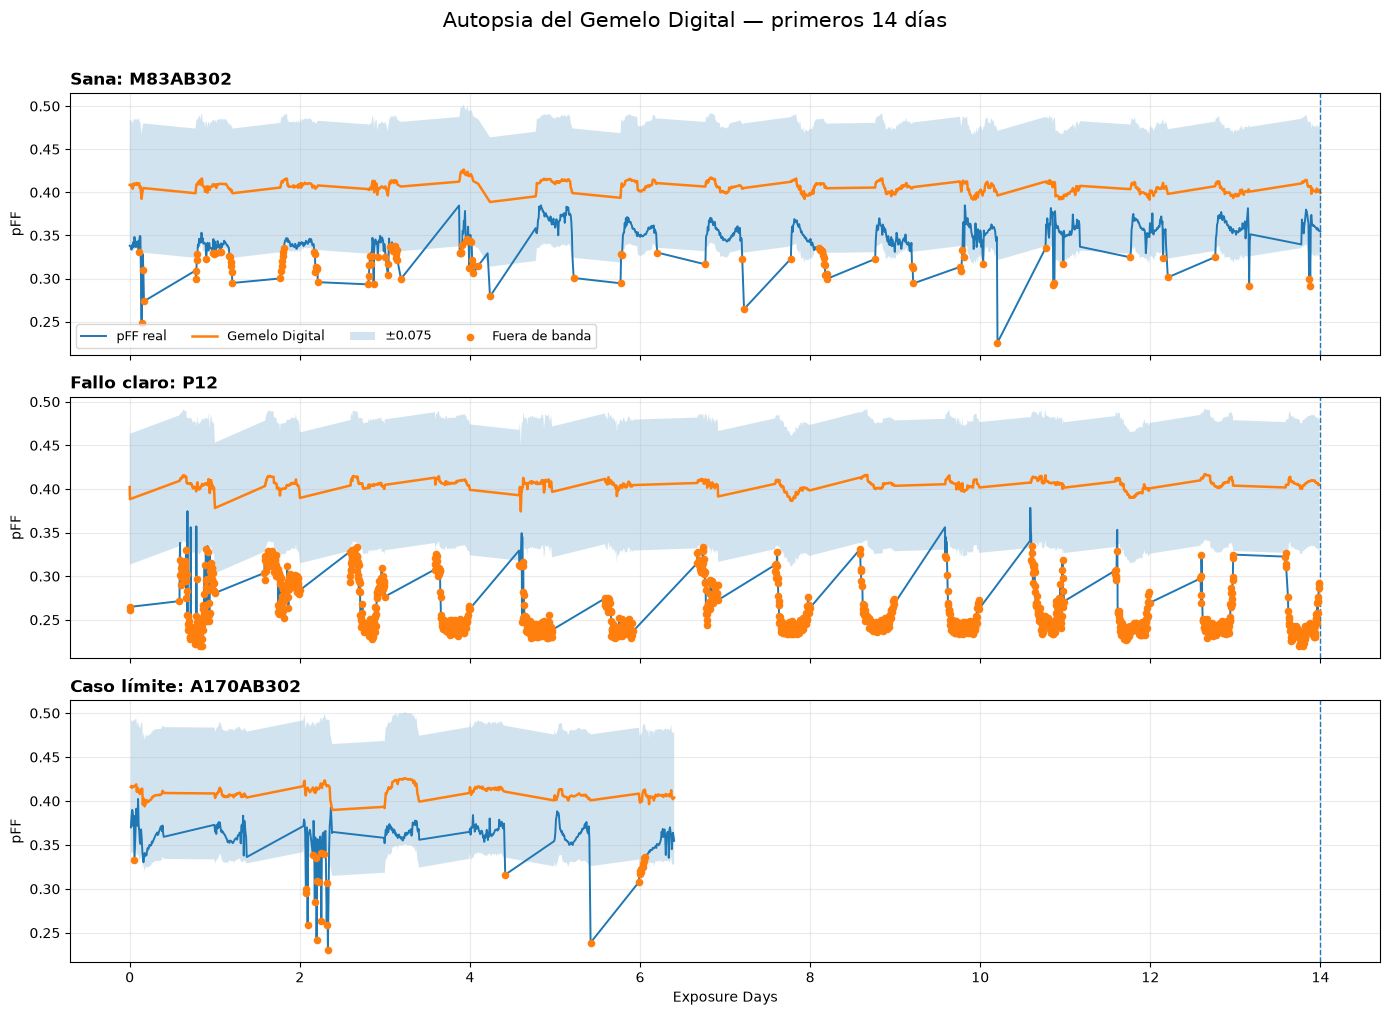

In [3]:
# ============================================================
# 3. AUTOPSIA COMPARATIVA — TRES CASOS ARQUETÍPICOS
# ============================================================

# Tres casos que queremos presentar en la tesis
CASE_STUDIES = {
    "Sana": "M83AB302",
    "Fallo claro": "P12",
    "Caso límite": "A170AB302",
}

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)

for ax, (label, cell) in zip(
    axes,
    CASE_STUDIES.items()
):

    # --------------------------------------------------------
    # IMPORTANTE:
    # usamos SOLO observaciones donde existe predicción
    # del Gemelo Digital
    # --------------------------------------------------------

    data = df[
        (df["cell_name"] == cell) &
        (df["Exposure_Days"] <= EARLY_DAYS) &
        (df["Twin_pFF_Pred"].notna())
    ].copy()

    print(
        f"{label:15s} | "
        f"{cell:12s} | "
        f"{len(data):4d} observaciones con predicción"
    )

    if data.empty:
        ax.text(
            0.5,
            0.5,
            f"SIN DATOS CON PREDICCIÓN\n{cell}",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=13,
        )
        continue

    data = data.sort_values("Exposure_Days")

    x = data["Exposure_Days"]
    real = data["pFF"]
    pred = data["Twin_pFF_Pred"]
    residual = data["Residual_pFF"]

    # --------------------------------------------------------
    # CURVA REAL
    # --------------------------------------------------------

    ax.plot(
        x,
        real,
        linewidth=1.4,
        label="pFF real",
    )

    # --------------------------------------------------------
    # GEMELO DIGITAL
    # --------------------------------------------------------

    ax.plot(
        x,
        pred,
        linewidth=1.8,
        label="Gemelo Digital",
    )

    # --------------------------------------------------------
    # BANDA DE TOLERANCIA
    # --------------------------------------------------------

    ax.fill_between(
        x,
        pred - THRESHOLD_X3,
        pred + THRESHOLD_X3,
        alpha=0.20,
        label=r"$\pm 0.075$",
    )

    # --------------------------------------------------------
    # OBSERVACIONES FUERA DE BANDA
    # --------------------------------------------------------

    outside = (
        data["Abs_Residual_pFF"]
        > THRESHOLD_X3
    )

    ax.scatter(
        x[outside],
        real[outside],
        s=20,
        label="Fuera de banda",
        zorder=5,
    )

    # --------------------------------------------------------
    # LÍNEA DE LOS 14 DÍAS
    # --------------------------------------------------------

    ax.axvline(
        EARLY_DAYS,
        linestyle="--",
        linewidth=1,
    )

    ax.set_ylabel("pFF")

    ax.set_title(
        f"{label}: {cell}",
        loc="left",
        fontweight="bold",
    )

    ax.grid(alpha=0.25)

# Leyenda solo una vez
axes[0].legend(
    ncols=4,
    fontsize=9,
)

axes[-1].set_xlabel(
    "Exposure Days"
)

plt.suptitle(
    "Autopsia del Gemelo Digital — primeros 14 días",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_case_autopsy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

RESIDUOS DEL GEMELO DIGITAL — COHORTE SANA

Observaciones: 2,917
MAE absoluto: 0.02263


,Quantile,Threshold,Coverage_%
0,0.900000,0.04042,89.99
1,0.950000,0.05219,94.99
2,0.975000,0.06901,97.50
3,0.980000,0.07443,97.98
4,0.990000,0.10387,98.97
5,0.995000,0.12160,99.49
6,0.999000,0.15623,99.90



UMBRAL ACTUAL
-------------
0.025 → 68.32% cobertura
0.075 → 97.98% cobertura


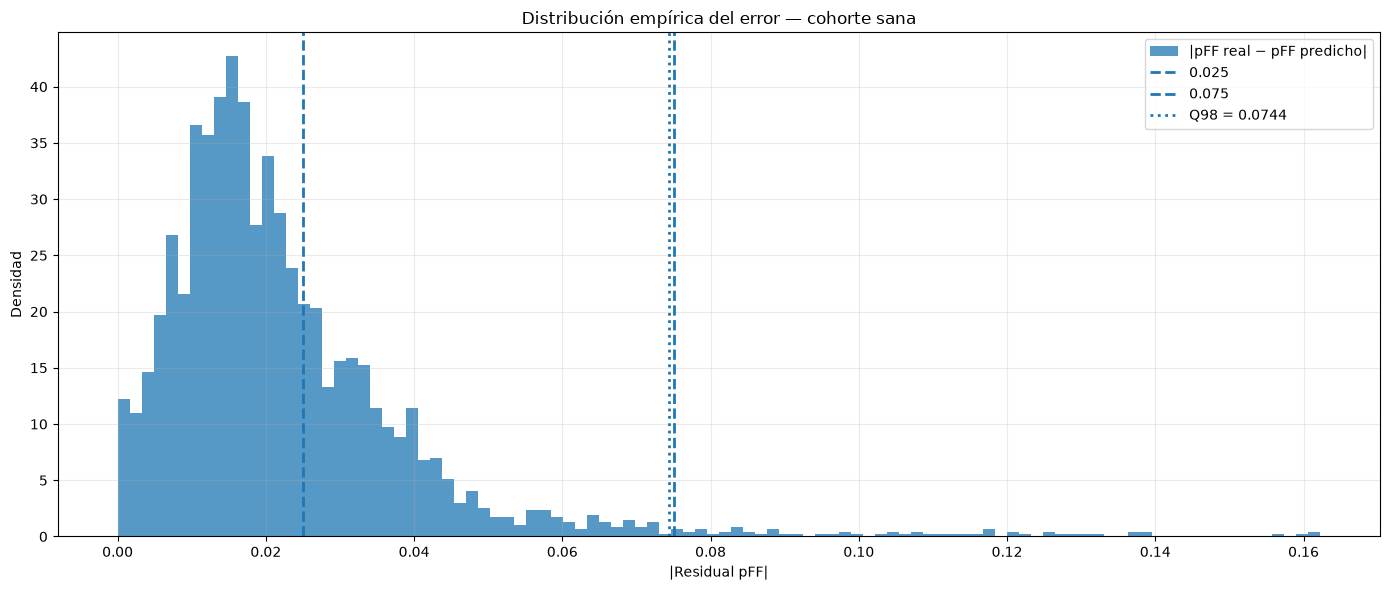

In [4]:
# ============================================================
# 4. DISTRIBUCIÓN EMPÍRICA DE RESIDUOS
# ============================================================

# ------------------------------------------------------------
# COHORTE SANA
# ------------------------------------------------------------

healthy = df[
    df["cell_name"].isin(["M83AB302", "ASLRXAB341"]) &
    (df["Exposure_Days"] > EARLY_DAYS) &
    df["Twin_pFF_Pred"].notna()
].copy()

healthy = healthy.dropna(
    subset=["Abs_Residual_pFF"]
)

abs_residual = healthy["Abs_Residual_pFF"]

print("=" * 80)
print("RESIDUOS DEL GEMELO DIGITAL — COHORTE SANA")
print("=" * 80)

print(f"\nObservaciones: {len(healthy):,}")
print(
    f"MAE absoluto: "
    f"{abs_residual.mean():.5f}"
)

# ------------------------------------------------------------
# CUANTILES
# ------------------------------------------------------------

quantiles = [
    0.90,
    0.95,
    0.975,
    0.98,
    0.99,
    0.995,
    0.999,
]

threshold_table = pd.DataFrame({
    "Quantile": quantiles,
    "Threshold": [
        abs_residual.quantile(q)
        for q in quantiles
    ],
})

threshold_table["Coverage_%"] = [
    (abs_residual <= t).mean() * 100
    for t in threshold_table["Threshold"]
]

display(
    threshold_table.style.format({
        "Threshold": "{:.5f}",
        "Coverage_%": "{:.2f}",
    })
)

# ------------------------------------------------------------
# COMPARACIÓN CON 0.025 Y 0.075
# ------------------------------------------------------------

print("\nUMBRAL ACTUAL")
print("-------------")

for threshold in [0.025, 0.075]:

    coverage = (
        abs_residual <= threshold
    ).mean() * 100

    print(
        f"{threshold:.3f} → "
        f"{coverage:.2f}% cobertura"
    )

# ------------------------------------------------------------
# HISTOGRAMA
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.hist(
    abs_residual,
    bins=100,
    density=True,
    alpha=0.75,
    label="|pFF real − pFF predicho|",
)

ax.axvline(
    0.025,
    linestyle="--",
    linewidth=2,
    label="0.025",
)

ax.axvline(
    0.075,
    linestyle="--",
    linewidth=2,
    label="0.075",
)

# Q98
q98 = abs_residual.quantile(0.98)

ax.axvline(
    q98,
    linestyle=":",
    linewidth=2,
    label=f"Q98 = {q98:.4f}",
)

ax.set_xlabel(
    "|Residual pFF|"
)

ax.set_ylabel(
    "Densidad"
)

ax.set_title(
    "Distribución empírica del error — cohorte sana"
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "empirical_residual_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

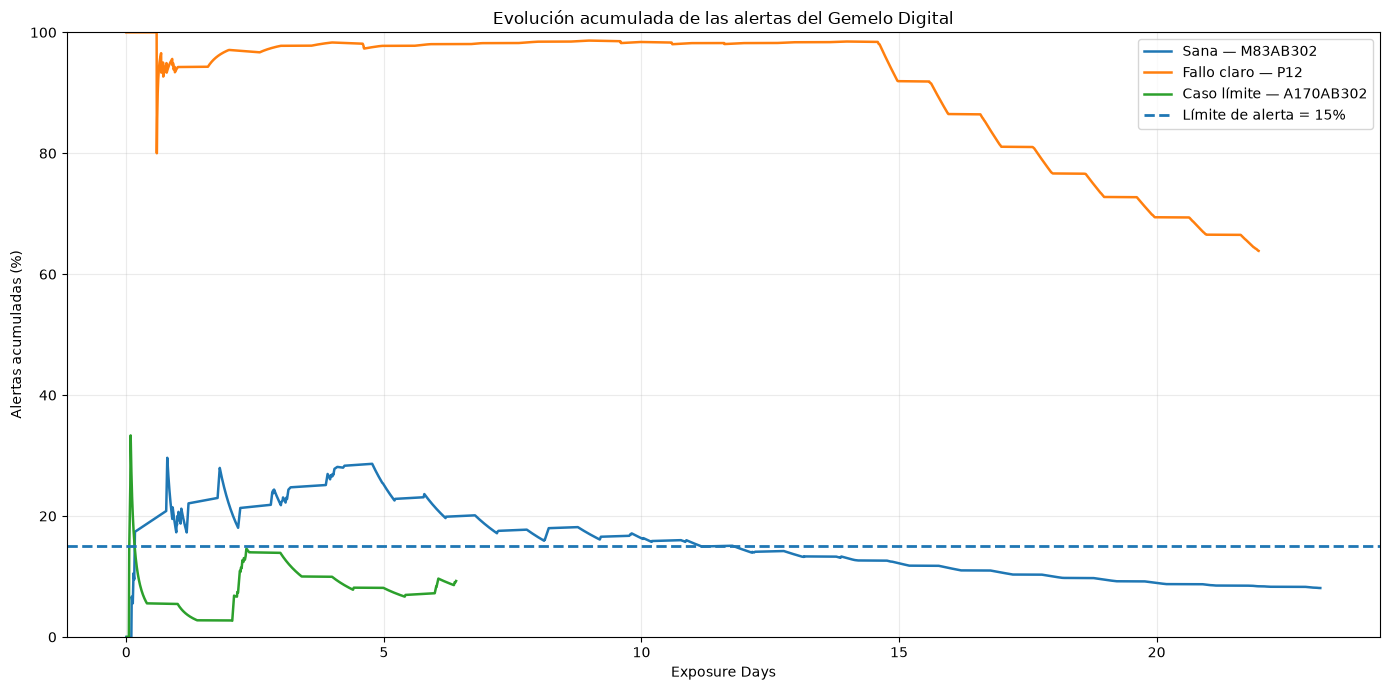

In [5]:
# ============================================================
# 5. TIMELINE DE ALERTAS — SOLO OBSERVACIONES PREDICHAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

timeline_results = {}

for label, cell in CASE_STUDIES.items():

    data = df[
        (df["cell_name"] == cell) &
        df["Twin_pFF_Pred"].notna()
    ].copy()

    if data.empty:
        continue

    data = data.sort_values(
        "Exposure_Days"
    )

    # --------------------------------------------------------
    # ALERTA DEL GEMELO DIGITAL
    # --------------------------------------------------------

    data["alert_numeric"] = (
        data["Digital_Twin_Alert"]
        .astype(bool)
        .astype(int)
    )

    # --------------------------------------------------------
    # ACUMULACIÓN
    # --------------------------------------------------------

    data["Cumulative_Alerts"] = (
        data["alert_numeric"]
        .cumsum()
    )

    data["N_Predictions"] = (
        np.arange(len(data)) + 1
    )

    data["Alert_Frequency"] = (
        data["Cumulative_Alerts"]
        /
        data["N_Predictions"]
    )

    timeline_results[cell] = data

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    ax.plot(
        data["Exposure_Days"],
        data["Alert_Frequency"] * 100,
        linewidth=1.8,
        label=f"{label} — {cell}",
    )

# ------------------------------------------------------------
# LÍMITE ACTUAL
# ------------------------------------------------------------

ax.axhline(
    ALERT_FREQ_LIMIT * 100,
    linestyle="--",
    linewidth=2,
    label="Límite de alerta = 15%",
)

ax.set_xlabel(
    "Exposure Days"
)

ax.set_ylabel(
    "Alertas acumuladas (%)"
)

ax.set_ylim(0, 100)

ax.set_title(
    "Evolución acumulada de las alertas del Gemelo Digital"
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_case_alert_timeline.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# ============================================================
# CRUCE DEL 15 %
# ============================================================

print("=" * 80)
print("PRIMER CRUCE DEL 15 % DE ALERTAS")
print("=" * 80)

for label, cell in CASE_STUDIES.items():

    timeline = timeline_results.get(cell)

    if timeline is None:
        print(f"{cell}: sin datos")
        continue

    crossed = timeline[
        timeline["Alert_Frequency"]
        >= ALERT_FREQ_LIMIT
    ]

    if crossed.empty:

        print(
            f"{cell:12s} → "
            "NO alcanza el 15%"
        )

    else:

        first = crossed.iloc[0]

        print(
            f"{cell:12s} → "
            f"día {first['Exposure_Days']:.3f}"
        )

PRIMER CRUCE DEL 15 % DE ALERTAS
M83AB302     → día 0.168
P12          → día 0.000
A170AB302    → día 0.077
